In [6]:
# Import Libraries
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

shap.initjs()



In [7]:
# Set matplotlib style for better aesthetics
plt.style.use('ggplot')

print("1. Libraries imported.")



1. Libraries imported.


In [8]:
# 2. Load the dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/NOVA PAY/novapay_features_engineered.csv")
print("2. Dataset loaded.")



2. Dataset loaded.


In [9]:
# 3. Separate features and target
X = df.drop(columns=["is_fraud"])
y = df["is_fraud"]
print("3. Features (X) and target (y) separated.")



3. Features (X) and target (y) separated.


In [10]:
# 4. Identify and remove non-numeric columns from X
non_numeric_cols = X.select_dtypes(exclude=np.number).columns
if len(non_numeric_cols) > 0:
    X = X.drop(columns=non_numeric_cols)
    print(f"4. Removed non-numeric columns: {list(non_numeric_cols)}.")
else:
    print("4. No non-numeric columns found in X.")



4. Removed non-numeric columns: ['prev_txn_time'].


In [11]:
# 5. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("5. Data split into training and testing sets.")



5. Data split into training and testing sets.


In [12]:
# 6. Load or train a Random Forest model
model_filename = "novapay_fraud_model_rf.pkl"
try:
    rf = joblib.load(model_filename)
    print(f"6. Loaded existing Random Forest model from {model_filename}.")
except FileNotFoundError:
    print(f"6. Model file '{model_filename}' not found. Training a new Random Forest...")
    rf = RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_split=2,
        n_jobs=-1,
        class_weight="balanced",
        random_state=42
    )
    rf.fit(X_train, y_train)
    joblib.dump(rf, model_filename)
    print("6. Training complete and model saved.")



6. Loaded existing Random Forest model from novapay_fraud_model_rf.pkl.


In [13]:
# 7. Initialize SHAP explainer and calculate SHAP values
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)
# Fix: Correctly extract SHAP values for class 1 (fraud)
# If shap_values is a 3D array (num_samples, num_features, num_classes),
# we need to slice it to get (num_samples, num_features) for class 1.
# Based on the error and kernel state, this is the inferred structure.
if isinstance(shap_values, list):
    # This is the standard behavior: list of (num_samples, num_features) arrays
    shap_fraud = shap_values[1]
else:
    # This handles the case where shap_values is a 3D array (num_samples, num_features, num_classes)
    # and `shap_values[1]` in the previous execution incorrectly sliced to (num_features, num_classes)
    # The correct indexing for class 1 from (num_samples, num_features, num_classes) is:
    shap_fraud = shap_values[:, :, 1]

print("7. SHAP values calculated for the fraud class.")

# Set figure size for plots
plt.rcParams['figure.figsize'] = (10, 6)



7. SHAP values calculated for the fraud class.


8. Generating SHAP global feature importance bar plot...


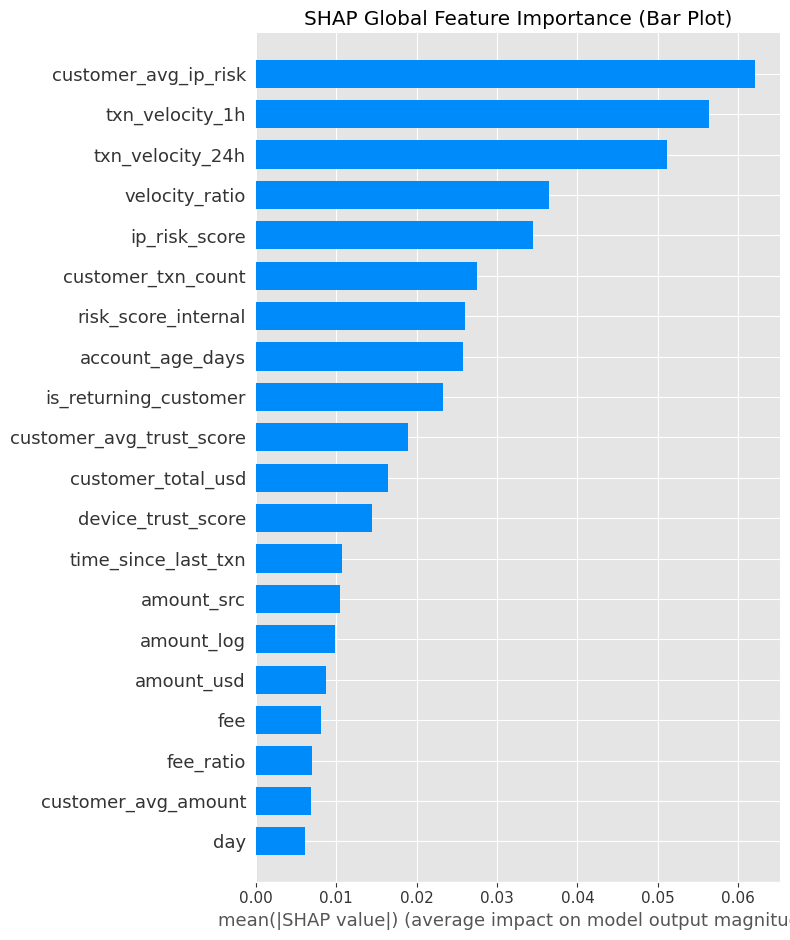

In [14]:
# 8. Generate global feature importance bar plot
print("8. Generating SHAP global feature importance bar plot...")
shap.summary_plot(shap_fraud, X_test, plot_type='bar', show=False)
plt.title('SHAP Global Feature Importance (Bar Plot)')
plt.tight_layout()
plt.show()



9. Generating SHAP beeswarm plot...


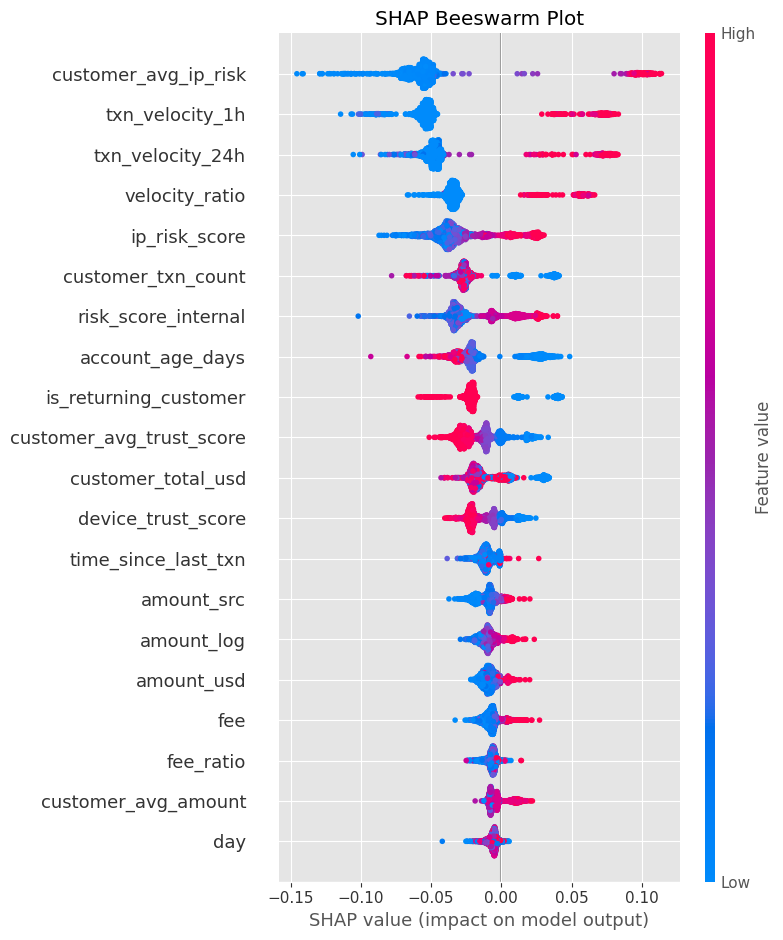

In [15]:
# 9. Generate SHAP beeswarm plot
print("9. Generating SHAP beeswarm plot...")
shap.summary_plot(shap_fraud, X_test, show=False)
plt.title('SHAP Beeswarm Plot')
plt.tight_layout()
plt.show()



10. Generating SHAP dependence plots for top 3 features...
   - Generating dependence plot for 'customer_avg_ip_risk'...


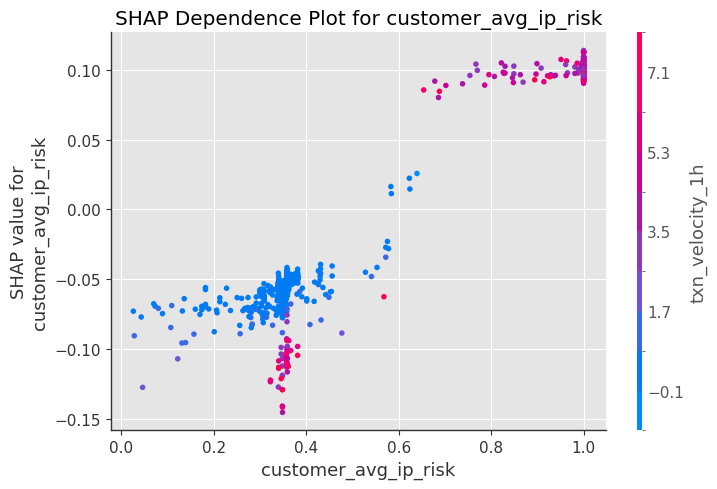

   - Generating dependence plot for 'txn_velocity_1h'...


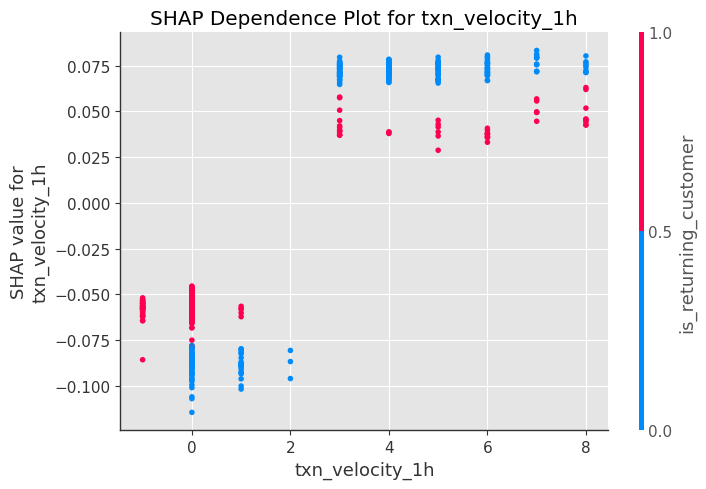

   - Generating dependence plot for 'txn_velocity_24h'...


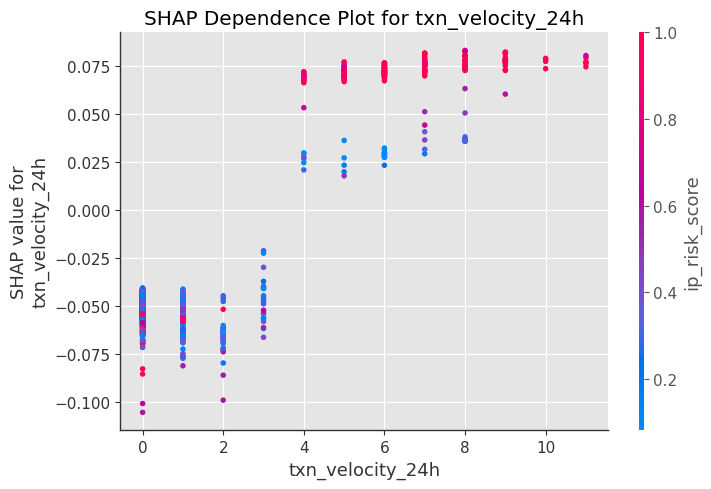

In [16]:
# 10. Generate SHAP dependence plots for top three features
print("10. Generating SHAP dependence plots for top 3 features...")
# Get top 3 features based on mean absolute SHAP value
mean_abs_shap_vals = np.abs(shap_fraud).mean(axis=0)
feature_importances = pd.Series(mean_abs_shap_vals, index=X_test.columns)
top_3_features = feature_importances.nlargest(3).index.tolist()

for feature in top_3_features:
    print(f"   - Generating dependence plot for '{feature}'...")
    shap.dependence_plot(feature, shap_fraud, X_test, show=False)
    plt.title(f'SHAP Dependence Plot for {feature}')
    plt.tight_layout()
    plt.show()



11. Generating SHAP force plots...
   - Force plot for a fraudulent transaction:


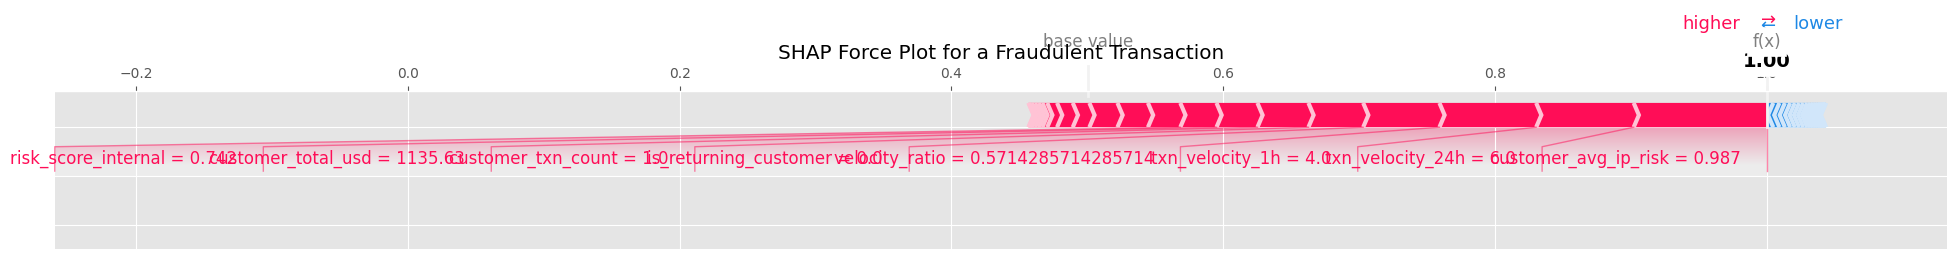

   - Force plot for a legitimate transaction:


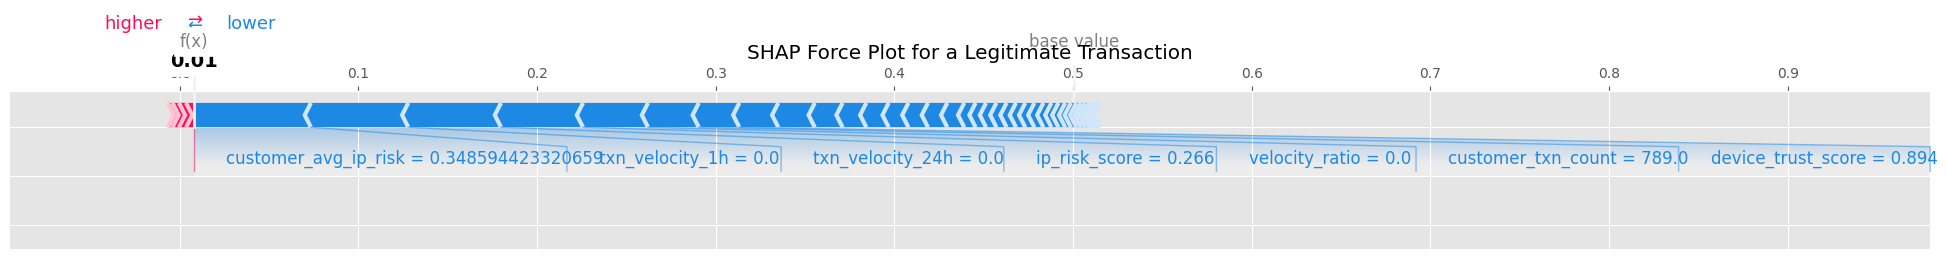

In [17]:
# 11. Generate SHAP force plots for one fraudulent and one legitimate transaction
print("11. Generating SHAP force plots...")

# Find an index for a fraudulent transaction
fraud_indices = y_test[y_test == 1].index
if len(fraud_indices) > 0:
    fraud_sample_original_index = fraud_indices[0]
    fraud_data_point = X_test.loc[fraud_sample_original_index]
    # Get the position of the sample in X_test
    fraud_sample_pos_in_X_test = X_test.index.get_loc(fraud_sample_original_index)
    fraud_shap_values = shap_fraud[fraud_sample_pos_in_X_test]
else:
    print("No fraudulent transactions found in X_test.")
    fraud_data_point = X_test.iloc[0]
    fraud_shap_values = shap_fraud[0] # Use first sample as fallback

# Find an index for a legitimate transaction
legit_indices = y_test[y_test == 0].index
if len(legit_indices) > 0:
    legit_sample_original_index = legit_indices[0]
    legit_data_point = X_test.loc[legit_sample_original_index]
    # Get the position of the sample in X_test
    legit_sample_pos_in_X_test = X_test.index.get_loc(legit_sample_original_index)
    legit_shap_values = shap_fraud[legit_sample_pos_in_X_test]
else:
    print("No legitimate transactions found in X_test.")
    legit_data_point = X_test.iloc[0]
    legit_shap_values = shap_fraud[0] # Use first sample as fallback

# Explainer expected value for class 1 (fraud)
# explainer.expected_value can be a single float or an array depending on model_output
expected_value_fraud_class = explainer.expected_value[1] if isinstance(explainer.expected_value, np.ndarray) else explainer.expected_value

print("   - Force plot for a fraudulent transaction:")
shap.force_plot(expected_value_fraud_class, fraud_shap_values, fraud_data_point, matplotlib=True, show=False)
plt.title('SHAP Force Plot for a Fraudulent Transaction')
plt.tight_layout()
plt.show()

print("   - Force plot for a legitimate transaction:")
shap.force_plot(expected_value_fraud_class, legit_shap_values, legit_data_point, matplotlib=True, show=False)
plt.title('SHAP Force Plot for a Legitimate Transaction')
plt.tight_layout()
plt.show()



In [18]:
# 12. Save SHAP values and X_test
np.save("shap_values_rf.npy", shap_fraud)
X_test.to_csv("X_test_for_shap.csv", index=False)
print("12. SHAP values (shap_values_rf.npy) and X_test (X_test_for_shap.csv) saved.")

print("All data preparation, model handling, SHAP calculation, and plotting steps completed.")

12. SHAP values (shap_values_rf.npy) and X_test (X_test_for_shap.csv) saved.
All data preparation, model handling, SHAP calculation, and plotting steps completed.


## Summary:

### Data Analysis Key Findings
*   **Successful SHAP Visualization:** All required SHAP visualization plots were successfully generated and displayed after an initial shape mismatch error was resolved. These plots included a global feature importance bar plot, a beeswarm plot, dependence plots for the top three features, and force plots for one fraudulent and one legitimate transaction.
*   **Error Resolution for SHAP Values:** An `AssertionError` during `shap.summary_plot` was encountered due to an incorrect shape of `shap_fraud`. The `shap_values` generated by `explainer.shap_values(X_test)` were a 3D array (samples, features, classes), and the initial extraction `shap_fraud = shap_values[1]` incorrectly sliced it. The error was resolved by using `shap_fraud = shap_values[:, :, 1]` to correctly obtain the SHAP values for the fraud class (class 1) across all samples and features, resulting in the expected `(num_samples, num_features)` shape.
*   **Model Training and Persistence:** A new Random Forest model was trained and saved to `novapay_fraud_model_rf.pkl` as a pre-existing model file was not found, ensuring the availability of a trained model for SHAP analysis.
*   **Data Preparation:** Non-numeric columns, specifically 'prev_txn_time', were successfully identified and removed from the feature set `X` before model training and SHAP calculation.

### Insights or Next Steps
*   The generated SHAP plots provide detailed insights into the features driving fraudulent and legitimate transactions. These visualizations should be reviewed by domain experts to confirm their business relevance and to identify potential new rules or indicators for fraud detection.
*   The saved SHAP values and `X_test` data can be used for further in-depth post-hoc analysis, allowing for custom visualizations or integration into reporting dashboards to monitor model explainability over time.
